In [1]:
import os
import sys
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

# PathoScope directories
DATA_DIR_07 = Path(
    "/content/drive/MyDrive/PathoScope/data"
)

RESULTS_DIR_07 = (
    DATA_DIR_07 / "notebook_07_results"
)

RESULTS_DIR_07.mkdir(
    parents=True,
    exist_ok=True
)

print()
print("Data directory:")
print(DATA_DIR_07)

print()
print("Notebook 07 results directory:")
print(RESULTS_DIR_07)

print()
print("Data directory exists:", DATA_DIR_07.exists())
print("Results directory exists:", RESULTS_DIR_07.exists())

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
CUDA available: False
Mounted at /content/drive

Data directory:
/content/drive/MyDrive/PathoScope/data

Notebook 07 results directory:
/content/drive/MyDrive/PathoScope/data/notebook_07_results

Data directory exists: True
Results directory exists: True


In [2]:
# Required inputs from previous notebooks

required_files_07 = {
    "tiles.csv": DATA_DIR_07 / "tiles.csv",

    "DeepLab checkpoint":
        DATA_DIR_07
        / "notebook_04_results"
        / "deeplabv3plus_resnet34.pth",

    "Combined Attention-MIL checkpoint":
        DATA_DIR_07
        / "notebook_05_results"
        / "combined_attention_mil.pth",

    "Normalized tiles":
        DATA_DIR_07 / "tiles_norm.zip"
}

print("Notebook 07 input check")
print("-----------------------")

for name, path in required_files_07.items():

    exists = path.exists()

    print(
        f"{name:35s} : "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    if exists and path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"  Size: {size_mb:.2f} MB")

print()
print("Notebook 07 output directory:")
print(RESULTS_DIR_07)

print()
print("Existing output files:")

for path in sorted(RESULTS_DIR_07.iterdir()):
    if path.is_file():
        print(" ", path.name)


Notebook 07 input check
-----------------------
tiles.csv                           : FOUND
  Size: 2.85 MB
DeepLab checkpoint                  : FOUND
  Size: 257.07 MB
Combined Attention-MIL checkpoint   : FOUND
  Size: 1.51 MB
Normalized tiles                    : FOUND
  Size: 411.67 MB

Notebook 07 output directory:
/content/drive/MyDrive/PathoScope/data/notebook_07_results

Existing output files:
  deeplabv3plus_resnet34.onnx
  deeplabv3plus_resnet34.onnx.data
  fig_07_slide_report.png
  onnx_benchmark.csv
  slide_results.csv


In [3]:
tiles_csv_07 = DATA_DIR_07 / "tiles.csv"

tiles_df_07 = pd.read_csv(
    tiles_csv_07
)

print("tiles.csv loaded")
print("----------------")

print("Shape:", tiles_df_07.shape)

print()
print("Columns:")
print(tiles_df_07.columns.tolist())

print()
print("Number of slides:")
print(tiles_df_07["image_id"].nunique())

print()
print("Tiles per slide:")
print(
    tiles_df_07
    .groupby("image_id")
    .size()
    .value_counts()
    .sort_index()
)

print()
print("ISUP distribution:")
print(
    tiles_df_07[
        ["image_id", "isup_grade"]
    ]
    .drop_duplicates()["isup_grade"]
    .value_counts()
    .sort_index()
)

print()
print("Tile-label distribution:")
print(
    tiles_df_07["tile_label"]
    .value_counts()
    .sort_index()
)

tiles.csv loaded
----------------
Shape: (12800, 13)

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

Number of slides:
200

Tiles per slide:
64    200
Name: count, dtype: int64

ISUP distribution:
isup_grade
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

Tile-label distribution:
tile_label
-1     838
 0    8569
 1    3393
Name: count, dtype: int64


In [4]:
import zipfile

NORM_DIR_07 = Path(
    "/content/pathoscope_07/tiles_norm"
)

NORM_DIR_07.mkdir(
    parents=True,
    exist_ok=True
)

norm_zip_07 = DATA_DIR_07 / "tiles_norm.zip"

# Extract only if the directory is not already populated
existing_norm_files_07 = list(
    NORM_DIR_07.glob("*.jpg")
)

if len(existing_norm_files_07) != len(tiles_df_07):

    print("Extracting normalized tiles...")

    with zipfile.ZipFile(
        norm_zip_07,
        "r"
    ) as z:
        z.extractall(NORM_DIR_07)

    print("Extraction complete.")

else:
    print(
        "Normalized tiles already extracted. "
        "Skipping extraction."
    )

# Map each CSV tile to its normalized image
tiles_df_07["norm_path"] = tiles_df_07[
    "image_path"
].apply(
    lambda p: NORM_DIR_07 / Path(p).name
)

exists_mask_07 = tiles_df_07[
    "norm_path"
].map(Path.exists)

print()
print("Total tiles:", len(tiles_df_07))
print(
    "Normalized files found:",
    exists_mask_07.sum()
)
print(
    "Missing normalized files:",
    (~exists_mask_07).sum()
)

print()
print("Example mappings:")

display(
    tiles_df_07[
        [
            "tile_id",
            "image_id",
            "x",
            "y",
            "norm_path"
        ]
    ].head()
)

if (~exists_mask_07).sum() == 0:
    print()
    print("✓ All 12,800 tiles successfully mapped.")
else:
    print()
    print("⚠ Missing normalized tiles detected.")

Extracting normalized tiles...
Extraction complete.

Total tiles: 12800
Normalized files found: 12800
Missing normalized files: 0

Example mappings:


,tile_id,image_id,x,y,norm_path
0,8f264374ed3fa427615c1650218e7f21_x1536_y1536,8f264374ed3fa427615c1650218e7f21,1536,1536,/content/pathoscope_07/tiles_norm/8f264374ed3f...
1,8f264374ed3fa427615c1650218e7f21_x1792_y4864,8f264374ed3fa427615c1650218e7f21,1792,4864,/content/pathoscope_07/tiles_norm/8f264374ed3f...
2,8f264374ed3fa427615c1650218e7f21_x2560_y7936,8f264374ed3fa427615c1650218e7f21,2560,7936,/content/pathoscope_07/tiles_norm/8f264374ed3f...
3,8f264374ed3fa427615c1650218e7f21_x2048_y8448,8f264374ed3fa427615c1650218e7f21,2048,8448,/content/pathoscope_07/tiles_norm/8f264374ed3f...
4,8f264374ed3fa427615c1650218e7f21_x2560_y8448,8f264374ed3fa427615c1650218e7f21,2560,8448,/content/pathoscope_07/tiles_norm/8f264374ed3f...



✓ All 12,800 tiles successfully mapped.


In [5]:
!pip install -q segmentation-models-pytorch==0.5.0
import torch
import segmentation_models_pytorch as smp

SEG_CHECKPOINT_07 = (
    DATA_DIR_07
    / "notebook_04_results"
    / "deeplabv3plus_resnet34.pth"
)

print("Segmentation checkpoint:")
print(SEG_CHECKPOINT_07)

checkpoint_seg_07 = torch.load(
    SEG_CHECKPOINT_07,
    map_location="cpu",
    weights_only=False
)

print()
print("Checkpoint type:", type(checkpoint_seg_07))

if isinstance(checkpoint_seg_07, dict):
    print("Checkpoint keys:")
    print(list(checkpoint_seg_07.keys()))

# Exact architecture used in Notebook 04
seg_model_07 = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

seg_model_07.load_state_dict(
    checkpoint_seg_07["model_state_dict"]
)

seg_model_07.eval()

num_params_seg_07 = sum(
    p.numel()
    for p in seg_model_07.parameters()
)

print()
print("Model:", "DeepLabV3Plus")
print("Encoder:", "ResNet34")
print("Input channels:", 3)
print("Output classes:", 1)
print("Parameters:", f"{num_params_seg_07:,}")

print()
print(
    "Training epoch:",
    checkpoint_seg_07.get("epoch")
)

print(
    "Best validation Dice:",
    checkpoint_seg_07.get("val_dice")
)

print(
    "Best validation IoU:",
    checkpoint_seg_07.get("val_iou")
)

print()
print("✓ Segmentation model loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.0 MB/s eta 0:00:00
Segmentation checkpoint:
/content/drive/MyDrive/PathoScope/data/notebook_04_results/deeplabv3plus_resnet34.pth

Checkpoint type: <class 'dict'>
Checkpoint keys:
['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_dice', 'val_iou']

Model: DeepLabV3Plus
Encoder: ResNet34
Input channels: 3
Output classes: 1
Parameters: 22,437,457

Training epoch: 10
Best validation Dice: 0.8097462289036592
Best validation IoU: 0.7952667223911762

✓ Segmentation model loaded successfully.


In [6]:
!pip install -q onnx==1.18.0 onnxscript==0.7.2 onnxruntime==1.22.0
import onnx
import onnxruntime as ort

ONNX_PATH_07 = (
    RESULTS_DIR_07
    / "deeplabv3plus_resnet34.onnx"
)

print("ONNX file:")
print(ONNX_PATH_07)

print()
print("Exists:", ONNX_PATH_07.exists())

if ONNX_PATH_07.exists():

    print(
        "File size:",
        f"{ONNX_PATH_07.stat().st_size / (1024**2):.2f} MB"
    )

    # Validate ONNX graph
    onnx_model_07 = onnx.load(
        str(ONNX_PATH_07)
    )

    onnx.checker.check_model(
        onnx_model_07
    )

    print()
    print("ONNX graph validation: PASSED")

    # Check ONNX Runtime
    session_07 = ort.InferenceSession(
        str(ONNX_PATH_07),
        providers=["CPUExecutionProvider"]
    )

    print()
    print(
        "ONNX Runtime version:",
        ort.__version__
    )

    print(
        "Input name:",
        session_07.get_inputs()[0].name
    )

    print(
        "Input shape:",
        session_07.get_inputs()[0].shape
    )

    print(
        "Output name:",
        session_07.get_outputs()[0].name
    )

    print(
        "Output shape:",
        session_07.get_outputs()[0].shape
    )

    print()
    print("✓ Existing ONNX model is valid.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.1 MB/s eta 0:00:00
ONNX file:
/content/drive/MyDrive/PathoScope/data/notebook_07_results/deeplabv3plus_resnet34.onnx

Exists: True
File size: 0.27 MB

ONNX graph validation: PASSED

ONNX Runtime version: 1.22.0
Input name: input
Input shape: ['batch', 3, 256, 256]
Output name: output
Output shape: ['batch', 1, 256, 256]

✓ Existing ONNX model is valid.


In [7]:
from pathlib import Path

TILES_NORM_07 = Path("/content/pathoscope_07/tiles_norm")

tile_paths_07 = sorted(TILES_NORM_07.glob("*.jpg"))

print("Normalized tile folder:", TILES_NORM_07)
print("Folder exists:", TILES_NORM_07.exists())
print("Number of normalized tiles:", len(tile_paths_07))

if len(tile_paths_07) == 0:
    raise FileNotFoundError("No normalized JPG tiles found.")

sample_tile_07 = tile_paths_07[0]

print("Sample tile:")
print(sample_tile_07)

Normalized tile folder: /content/pathoscope_07/tiles_norm
Folder exists: True
Number of normalized tiles: 12800
Sample tile:
/content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x10240_y2048.jpg


In [8]:
import numpy as np
import torch
import segmentation_models_pytorch as smp
from PIL import Image

# Load the exact DeepLabV3+ ResNet34 model
model_07 = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

checkpoint_path_07 = (
    DATA_DIR_07
    / "notebook_04_results"
    / "deeplabv3plus_resnet34.pth"
)

checkpoint_07 = torch.load(
    checkpoint_path_07,
    map_location="cpu",
    weights_only=False
)

model_07.load_state_dict(checkpoint_07["model_state_dict"])
model_07.eval()

print("PyTorch model loaded.")
print("Checkpoint epoch:", checkpoint_07["epoch"])
print("Validation Dice:", checkpoint_07["val_dice"])
print("Validation IoU:", checkpoint_07["val_iou"])

# Prepare the real normalized tile
img_07 = Image.open(sample_tile_07).convert("RGB").resize((256, 256))

x_07 = (
    torch.from_numpy(np.array(img_07))
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float() / 255.0
)

print("\nInput shape:", tuple(x_07.shape))

# PyTorch inference
with torch.no_grad():
    pytorch_output_07 = model_07(x_07)

# ONNX inference
onnx_input_name_07 = session_07.get_inputs()[0].name

onnx_output_07 = session_07.run(
    None,
    {onnx_input_name_07: x_07.numpy()}
)[0]

pytorch_output_np_07 = pytorch_output_07.cpu().numpy()

print("\nPyTorch output shape:", pytorch_output_np_07.shape)
print("ONNX output shape:", onnx_output_07.shape)

# Numerical comparison
max_abs_diff_07 = np.max(
    np.abs(pytorch_output_np_07 - onnx_output_07)
)

mean_abs_diff_07 = np.mean(
    np.abs(pytorch_output_np_07 - onnx_output_07)
)

print("\nPyTorch logits:")
print(
    "min =", float(pytorch_output_np_07.min()),
    "max =", float(pytorch_output_np_07.max())
)

print("\nONNX logits:")
print(
    "min =", float(onnx_output_07.min()),
    "max =", float(onnx_output_07.max())
)

print("\nMaximum absolute difference:", float(max_abs_diff_07))
print("Mean absolute difference:", float(mean_abs_diff_07))

if max_abs_diff_07 < 1e-3:
    print("\n✓ PyTorch and ONNX outputs match.")
else:
    print("\n⚠️ Difference is larger than expected.")

PyTorch model loaded.
Checkpoint epoch: 10
Validation Dice: 0.8097462289036592
Validation IoU: 0.7952667223911762

Input shape: (1, 3, 256, 256)

PyTorch output shape: (1, 1, 256, 256)
ONNX output shape: (1, 1, 256, 256)

PyTorch logits:
min = -15.895913124084473 max = -5.535750865936279

ONNX logits:
min = -15.895909309387207 max = -5.53574800491333

Maximum absolute difference: 2.002716064453125e-05
Mean absolute difference: 6.0487218433991075e-06

✓ PyTorch and ONNX outputs match.


In [9]:
import time
import pandas as pd
import numpy as np

# Use the same input for both models
x_numpy_07 = x_07.numpy()

# Warm-up
with torch.no_grad():
    for _ in range(5):
        _ = model_07(x_07)

for _ in range(5):
    _ = session_07.run(
        None,
        {onnx_input_name_07: x_numpy_07}
    )

# Benchmark settings
N_BENCH_07 = 20

# PyTorch benchmark
pytorch_times_07 = []

with torch.no_grad():
    for _ in range(N_BENCH_07):
        start = time.perf_counter()
        _ = model_07(x_07)
        end = time.perf_counter()
        pytorch_times_07.append(end - start)

# ONNX Runtime benchmark
onnx_times_07 = []

for _ in range(N_BENCH_07):
    start = time.perf_counter()
    _ = session_07.run(
        None,
        {onnx_input_name_07: x_numpy_07}
    )
    end = time.perf_counter()
    onnx_times_07.append(end - start)

# Convert to milliseconds
pytorch_ms_07 = np.array(pytorch_times_07) * 1000
onnx_ms_07 = np.array(onnx_times_07) * 1000

pytorch_mean_07 = pytorch_ms_07.mean()
pytorch_median_07 = np.median(pytorch_ms_07)

onnx_mean_07 = onnx_ms_07.mean()
onnx_median_07 = np.median(onnx_ms_07)

speed_ratio_07 = pytorch_mean_07 / onnx_mean_07

print("CPU benchmark")
print("=" * 40)

print(f"Runs: {N_BENCH_07}")

print("\nPyTorch:")
print(f"Mean:   {pytorch_mean_07:.3f} ms")
print(f"Median: {pytorch_median_07:.3f} ms")

print("\nONNX Runtime:")
print(f"Mean:   {onnx_mean_07:.3f} ms")
print(f"Median: {onnx_median_07:.3f} ms")

print("\nSpeed ratio:")
print(f"PyTorch / ONNX = {speed_ratio_07:.2f}x")

if speed_ratio_07 > 1:
    print("✓ ONNX Runtime is faster on this CPU benchmark.")
else:
    print("ONNX Runtime was not faster in this benchmark.")

# Save benchmark result
benchmark_df_07 = pd.DataFrame({
    "model": ["PyTorch", "ONNX Runtime"],
    "mean_ms": [pytorch_mean_07, onnx_mean_07],
    "median_ms": [pytorch_median_07, onnx_median_07],
    "runs": [N_BENCH_07, N_BENCH_07]
})

benchmark_path_07 = RESULTS_DIR_07 / "onnx_benchmark.csv"
benchmark_df_07.to_csv(benchmark_path_07, index=False)

print("\nSaved:", benchmark_path_07)

CPU benchmark
Runs: 20

PyTorch:
Mean:   1005.026 ms
Median: 854.985 ms

ONNX Runtime:
Mean:   598.126 ms
Median: 578.467 ms

Speed ratio:
PyTorch / ONNX = 1.68x
✓ ONNX Runtime is faster on this CPU benchmark.

Saved: /content/drive/MyDrive/PathoScope/data/notebook_07_results/onnx_benchmark.csv


In [10]:
import torch
import torch.nn as nn

COMBINED_MIL_PATH_07 = (
    DATA_DIR_07
    / "notebook_05_results"
    / "combined_attention_mil.pth"
)

mil_checkpoint_07 = torch.load(
    COMBINED_MIL_PATH_07,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded:", COMBINED_MIL_PATH_07)
print("Checkpoint keys:", list(mil_checkpoint_07.keys()))

print("\nModel configuration:")
print("Input dimension:", mil_checkpoint_07["input_dim"])
print("Hidden dimension:", mil_checkpoint_07["hidden_dim"])
print("Number of classes:", mil_checkpoint_07["num_classes"])
print("Best epoch:", mil_checkpoint_07["best_epoch"])
print("Best validation QWK:", mil_checkpoint_07["best_val_qwk"])


class AttentionMIL07(nn.Module):
    def __init__(
        self,
        input_dim=1284,
        hidden_dim=256,
        num_classes=6
    ):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):

        h = self.feature_projection(x)

        attention_logits = self.attention(h)

        attention_weights = torch.softmax(
            attention_logits,
            dim=1
        )

        slide_representation = torch.sum(
            attention_weights * h,
            dim=1
        )

        logits = self.classifier(
            slide_representation
        )

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


mil_model_07 = AttentionMIL07(
    input_dim=mil_checkpoint_07["input_dim"],
    hidden_dim=mil_checkpoint_07["hidden_dim"],
    num_classes=mil_checkpoint_07["num_classes"]
)

mil_model_07.load_state_dict(
    mil_checkpoint_07["model_state_dict"]
)

mil_model_07.eval()

total_params_07 = sum(
    p.numel()
    for p in mil_model_07.parameters()
)

print("\nAttention-MIL model loaded.")
print("Parameters:", total_params_07)
print("Expected parameters: 395655")

Checkpoint loaded: /content/drive/MyDrive/PathoScope/data/notebook_05_results/combined_attention_mil.pth
Checkpoint keys: ['model_state_dict', 'best_epoch', 'best_val_qwk', 'input_dim', 'hidden_dim', 'num_classes']

Model configuration:
Input dimension: 1284
Hidden dimension: 256
Number of classes: 6
Best epoch: 27
Best validation QWK: 0.5924170616113744

Attention-MIL model loaded.
Parameters: 395655
Expected parameters: 395655


In [11]:
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image
from pathlib import Path
import pandas as pd
import numpy as np
import torch

# Load tile metadata
tiles_df_07 = pd.read_csv(
    DATA_DIR_07 / "tiles.csv"
)

# Use the representative slide from the available normalized tiles
SLIDE_ID_07 = "008069b542b0439ed69b194674051964"

slide_df_07 = tiles_df_07[
    tiles_df_07["image_id"].astype(str) == SLIDE_ID_07
].copy()

print("Slide ID:", SLIDE_ID_07)
print("Number of tiles:", len(slide_df_07))

if len(slide_df_07) == 0:
    raise ValueError("Representative slide was not found in tiles.csv.")

# Sort spatially so feature order is deterministic
slide_df_07 = slide_df_07.sort_values(
    ["y", "x"]
).reset_index(drop=True)

# Map each tile to its normalized image
slide_df_07["norm_path"] = slide_df_07["image_path"].apply(
    lambda p: TILES_NORM_07 / Path(p).name
)

missing_07 = [
    str(p)
    for p in slide_df_07["norm_path"]
    if not p.exists()
]

print("Missing normalized tiles:", len(missing_07))

if missing_07:
    raise FileNotFoundError(
        f"Missing normalized tiles. First missing: {missing_07[0]}"
    )

# Load ImageNet-pretrained EfficientNet-B0
weights_07 = EfficientNet_B0_Weights.DEFAULT

efficientnet_07 = models.efficientnet_b0(
    weights=weights_07
)

# Remove final classifier to obtain 1280-D features
efficientnet_07.classifier = torch.nn.Identity()
efficientnet_07.eval()

preprocess_07 = weights_07.transforms()

efficientnet_params_07 = sum(
    p.numel()
    for p in efficientnet_07.parameters()
)

print("EfficientNet-B0 loaded.")
print("Feature dimension: 1280")
print("Parameters:", efficientnet_params_07)

print("\nFirst 5 tiles:")
print(
    slide_df_07[
        ["image_id", "x", "y", "norm_path"]
    ].head().to_string(index=False)
)

Slide ID: 008069b542b0439ed69b194674051964
Number of tiles: 64
Missing normalized tiles: 0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 116MB/s]


EfficientNet-B0 loaded.
Feature dimension: 1280
Parameters: 4007548

First 5 tiles:
                        image_id     x    y                                                                           norm_path
008069b542b0439ed69b194674051964 18432  768  /content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x18432_y768.jpg
008069b542b0439ed69b194674051964 17664 1024 /content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x17664_y1024.jpg
008069b542b0439ed69b194674051964 18688 1024 /content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x18688_y1024.jpg
008069b542b0439ed69b194674051964 19456 1024 /content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x19456_y1024.jpg
008069b542b0439ed69b194674051964 17920 1280 /content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x17920_y1280.jpg


In [12]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torch

class SlideTileDataset07(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            row["norm_path"]
        ).convert("RGB")

        image = self.transform(image)

        return image, idx


slide_dataset_07 = SlideTileDataset07(
    slide_df_07,
    preprocess_07
)

slide_loader_07 = DataLoader(
    slide_dataset_07,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

slide_features_1280_07 = []

with torch.no_grad():

    for batch_images_07, batch_indices_07 in slide_loader_07:

        features_07 = efficientnet_07(
            batch_images_07
        )

        slide_features_1280_07.append(
            features_07.cpu()
        )

slide_features_1280_07 = torch.cat(
    slide_features_1280_07,
    dim=0
)

print("EfficientNet feature shape:")
print(tuple(slide_features_1280_07.shape))

print(
    "Feature range:",
    float(slide_features_1280_07.min()),
    "to",
    float(slide_features_1280_07.max())
)

if slide_features_1280_07.shape == (64, 1280):
    print("\n✓ 64 tiles × 1280 EfficientNet features generated.")
else:
    raise ValueError(
        f"Unexpected feature shape: {slide_features_1280_07.shape}"
    )

EfficientNet feature shape:
(64, 1280)
Feature range: -0.26503050327301025 to 5.222177028656006

✓ 64 tiles × 1280 EfficientNet features generated.


In [13]:
seg_features_07 = []

with torch.no_grad():

    for batch_images_07, batch_indices_07 in slide_loader_07:

        # PyTorch segmentation inference
        logits_07 = model_07(batch_images_07)

        probabilities_07 = torch.sigmoid(logits_07)

        # Per-tile features
        mean_probability_07 = probabilities_07.mean(
            dim=(1, 2, 3)
        )

        max_probability_07 = probabilities_07.amax(
            dim=(1, 2, 3)
        )

        area_01_07 = (
            probabilities_07 >= 0.10
        ).float().mean(
            dim=(1, 2, 3)
        )

        area_05_07 = (
            probabilities_07 >= 0.50
        ).float().mean(
            dim=(1, 2, 3)
        )

        batch_seg_features_07 = torch.stack(
            [
                mean_probability_07,
                max_probability_07,
                area_01_07,
                area_05_07
            ],
            dim=1
        )

        seg_features_07.append(
            batch_seg_features_07.cpu()
        )

seg_features_07 = torch.cat(
    seg_features_07,
    dim=0
)

print("Segmentation feature shape:")
print(tuple(seg_features_07.shape))

print("\nFeature columns:")
print([
    "mean_probability",
    "max_probability",
    "area_01",
    "area_05"
])

print("\nFeature summary:")
print(
    "Mean probability:",
    float(seg_features_07[:, 0].mean())
)

print(
    "Max probability:",
    float(seg_features_07[:, 1].mean())
)

print(
    "Mean area >= 0.10:",
    float(seg_features_07[:, 2].mean())
)

print(
    "Mean area >= 0.50:",
    float(seg_features_07[:, 3].mean())
)

if seg_features_07.shape == (64, 4):
    print("\n✓ 64 tiles × 4 segmentation features generated.")
else:
    raise ValueError(
        f"Unexpected segmentation feature shape: {seg_features_07.shape}"
    )

Segmentation feature shape:
(64, 4)

Feature columns:
['mean_probability', 'max_probability', 'area_01', 'area_05']

Feature summary:
Mean probability: 0.09631214290857315
Max probability: 0.30629342794418335
Mean area >= 0.10: 0.12338817119598389
Mean area >= 0.50: 0.0966382697224617

✓ 64 tiles × 4 segmentation features generated.


In [14]:
seg_features_07 = []

with torch.no_grad():

    for batch_images_07, batch_indices_07 in slide_loader_07:

        # PyTorch segmentation inference
        logits_07 = model_07(batch_images_07)

        probabilities_07 = torch.sigmoid(logits_07)

        # Per-tile features
        mean_probability_07 = probabilities_07.mean(
            dim=(1, 2, 3)
        )

        max_probability_07 = probabilities_07.amax(
            dim=(1, 2, 3)
        )

        area_01_07 = (
            probabilities_07 >= 0.10
        ).float().mean(
            dim=(1, 2, 3)
        )

        area_05_07 = (
            probabilities_07 >= 0.50
        ).float().mean(
            dim=(1, 2, 3)
        )

        batch_seg_features_07 = torch.stack(
            [
                mean_probability_07,
                max_probability_07,
                area_01_07,
                area_05_07
            ],
            dim=1
        )

        seg_features_07.append(
            batch_seg_features_07.cpu()
        )

seg_features_07 = torch.cat(
    seg_features_07,
    dim=0
)

print("Segmentation feature shape:")
print(tuple(seg_features_07.shape))

print("\nFeature columns:")
print([
    "mean_probability",
    "max_probability",
    "area_01",
    "area_05"
])

print("\nFeature summary:")
print(
    "Mean probability:",
    float(seg_features_07[:, 0].mean())
)

print(
    "Max probability:",
    float(seg_features_07[:, 1].mean())
)

print(
    "Mean area >= 0.10:",
    float(seg_features_07[:, 2].mean())
)

print(
    "Mean area >= 0.50:",
    float(seg_features_07[:, 3].mean())
)

if seg_features_07.shape == (64, 4):
    print("\n✓ 64 tiles × 4 segmentation features generated.")
else:
    raise ValueError(
        f"Unexpected segmentation feature shape: {seg_features_07.shape}"
    )

Segmentation feature shape:
(64, 4)

Feature columns:
['mean_probability', 'max_probability', 'area_01', 'area_05']

Feature summary:
Mean probability: 0.09631214290857315
Max probability: 0.30629342794418335
Mean area >= 0.10: 0.12338817119598389
Mean area >= 0.50: 0.0966382697224617

✓ 64 tiles × 4 segmentation features generated.


In [15]:
# Combine EfficientNet and segmentation features
combined_tile_features_07 = torch.cat(
    [
        slide_features_1280_07,
        seg_features_07
    ],
    dim=1
)

print("EfficientNet features:")
print(tuple(slide_features_1280_07.shape))

print("Segmentation features:")
print(tuple(seg_features_07.shape))

print("\nCombined feature shape:")
print(tuple(combined_tile_features_07.shape))

print(
    "\nCombined feature range:",
    float(combined_tile_features_07.min()),
    "to",
    float(combined_tile_features_07.max())
)

if combined_tile_features_07.shape == (64, 1284):
    print("\n✓ Exact 64 × 1284 feature matrix created.")
else:
    raise ValueError(
        f"Unexpected combined feature shape: "
        f"{combined_tile_features_07.shape}"
    )

EfficientNet features:
(64, 1280)
Segmentation features:
(64, 4)

Combined feature shape:
(64, 1284)

Combined feature range: -0.26503050327301025 to 5.222177028656006

✓ Exact 64 × 1284 feature matrix created.


In [16]:
with torch.no_grad():

    logits_07, attention_weights_07 = mil_model_07(
        combined_tile_features_07.unsqueeze(0),
        return_attention=True
    )

probabilities_07 = torch.softmax(
    logits_07,
    dim=1
).squeeze(0)

predicted_isup_07 = int(
    torch.argmax(probabilities_07).item()
)

attention_weights_07 = attention_weights_07.squeeze(0)

print("Slide ID:", SLIDE_ID_07)

print("\nISUP probabilities:")
for grade_07, probability_07 in enumerate(probabilities_07):
    print(
        f"ISUP {grade_07}: "
        f"{float(probability_07):.6f}"
    )

print("\nPredicted ISUP grade:", predicted_isup_07)

print("\nAttention statistics:")
print(
    "Minimum:",
    float(attention_weights_07.min())
)

print(
    "Maximum:",
    float(attention_weights_07.max())
)

print(
    "Sum:",
    float(attention_weights_07.sum())
)

print(
    "Number of attention weights:",
    len(attention_weights_07)
)

if abs(float(attention_weights_07.sum()) - 1.0) < 1e-5:
    print("\n✓ Attention weights sum to 1.")
else:
    print("\n⚠️ Attention weights do not sum to 1.")

Slide ID: 008069b542b0439ed69b194674051964

ISUP probabilities:
ISUP 0: 0.051442
ISUP 1: 0.087665
ISUP 2: 0.162798
ISUP 3: 0.188314
ISUP 4: 0.266814
ISUP 5: 0.242966

Predicted ISUP grade: 4

Attention statistics:
Minimum: 0.000230806675972417
Maximum: 0.1944742351770401
Sum: 0.9999998211860657
Number of attention weights: 64

✓ Attention weights sum to 1.


In [17]:
# Add attention weights to the slide metadata
slide_attention_df_07 = slide_df_07[
    ["image_id", "x", "y", "norm_path"]
].copy()

slide_attention_df_07["attention"] = (
    attention_weights_07.cpu().numpy()
)

# Sort by attention from highest to lowest
top_attention_07 = slide_attention_df_07.sort_values(
    "attention",
    ascending=False
).reset_index(drop=True)

print("Top 10 attention tiles:\n")

print(
    top_attention_07[
        ["x", "y", "attention"]
    ].head(10).to_string(index=False)
)

print("\nAttention sum:")
print(
    float(top_attention_07["attention"].sum())
)

print("\nHighest-attention tile:")
print(
    top_attention_07.iloc[0]["norm_path"]
)

Top 10 attention tiles:

    x    y  attention
12288 2304   0.194474
12544 2048   0.177338
12544 2304   0.101159
12544 2560   0.044919
17664 1536   0.041048
13824 2560   0.030224
 8960 3072   0.029031
 7168 3840   0.025660
17664 2048   0.025019
18944 1280   0.023781

Attention sum:
0.9999997615814209

Highest-attention tile:
/content/pathoscope_07/tiles_norm/008069b542b0439ed69b194674051964_x12288_y2304.jpg


In [18]:
# Segmentation summary for the 64 tiles
seg_mean_probability_slide_07 = float(
    seg_features_07[:, 0].mean()
)

seg_max_probability_slide_07 = float(
    seg_features_07[:, 1].max()
)

seg_area_01_slide_07 = float(
    seg_features_07[:, 2].mean()
)

seg_area_05_slide_07 = float(
    seg_features_07[:, 3].mean()
)

# Maximum segmentation probability across all pixels/tiles
with torch.no_grad():
    max_seg_probability_07 = 0.0

    for batch_images_07, batch_indices_07 in slide_loader_07:

        logits_07 = model_07(batch_images_07)
        probabilities_07 = torch.sigmoid(logits_07)

        batch_max_07 = float(
            probabilities_07.max()
        )

        max_seg_probability_07 = max(
            max_seg_probability_07,
            batch_max_07
        )

# Ground-truth ISUP from the slide metadata
unique_isup_07 = slide_df_07["isup_grade"].dropna().unique()

print("Slide segmentation summary")
print("=" * 40)

print(
    "Mean tile tumor probability:",
    seg_mean_probability_slide_07
)

print(
    "Maximum pixel tumor probability:",
    max_seg_probability_07
)

print(
    "Mean tile area >= 0.10:",
    seg_area_01_slide_07
)

print(
    "Mean tile area >= 0.50:",
    seg_area_05_slide_07
)

print("\nGround-truth information")

print(
    "Unique ISUP grades in tiles:",
    unique_isup_07
)

if len(unique_isup_07) == 1:
    true_isup_07 = int(unique_isup_07[0])
    print("Ground-truth ISUP:", true_isup_07)
else:
    true_isup_07 = None
    print(
        "Ground-truth ISUP could not be represented "
        "by a single value."
    )

print("\nModel prediction:")
print("Predicted ISUP:", predicted_isup_07)

Slide segmentation summary
Mean tile tumor probability: 0.09631214290857315
Maximum pixel tumor probability: 0.997637152671814
Mean tile area >= 0.10: 0.12338817119598389
Mean tile area >= 0.50: 0.0966382697224617

Ground-truth information
Unique ISUP grades in tiles: [4]
Ground-truth ISUP: 4

Model prediction:
Predicted ISUP: 4


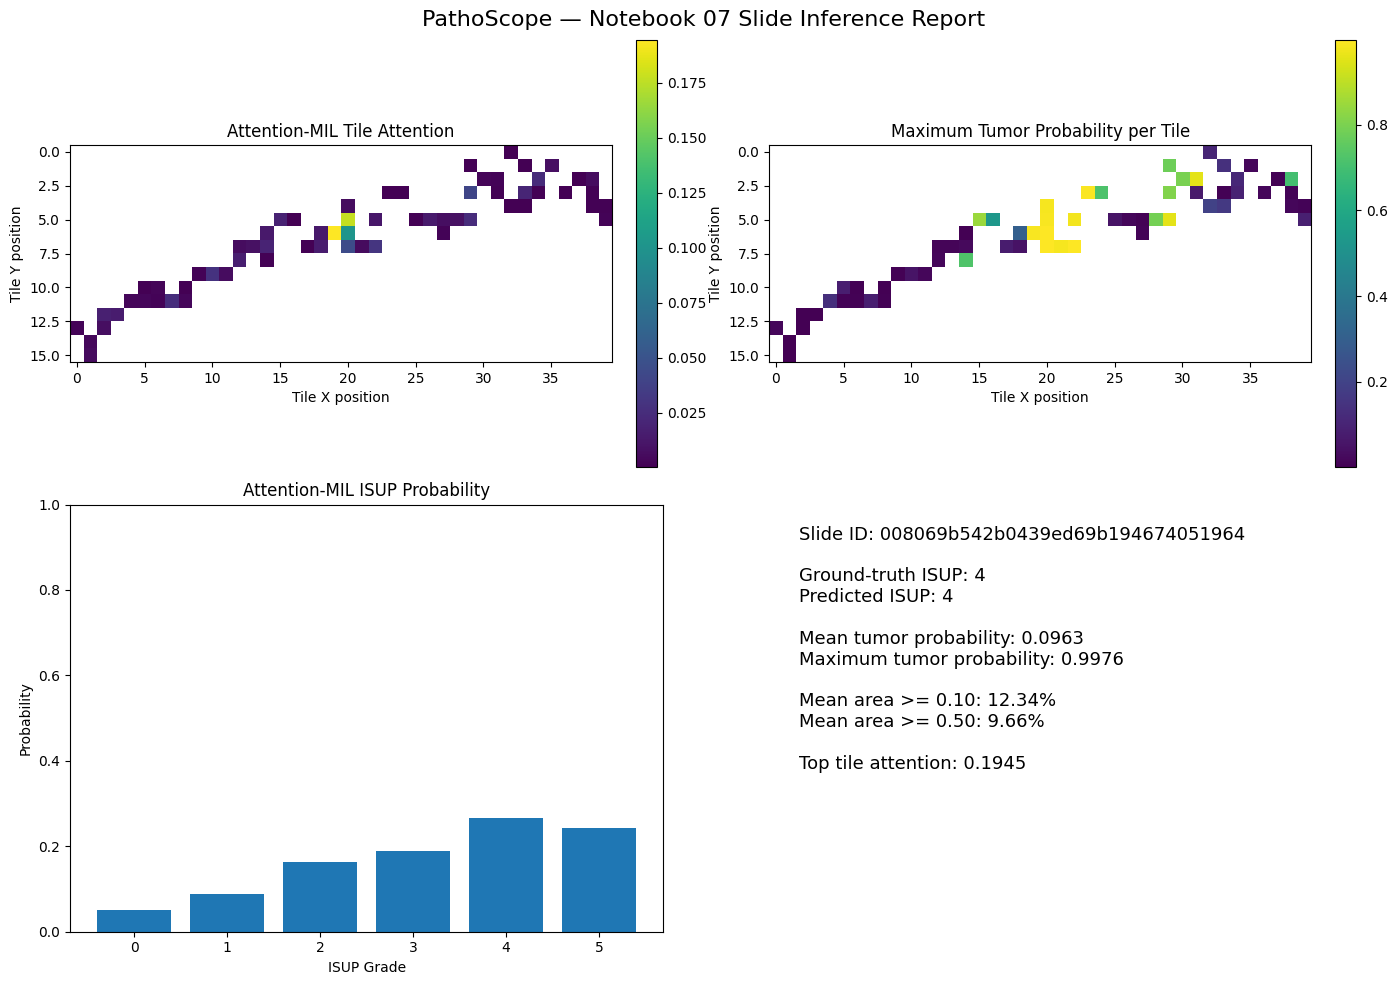


ISUP probabilities:
ISUP 0: 0.051442
ISUP 1: 0.087665
ISUP 2: 0.162798
ISUP 3: 0.188314
ISUP 4: 0.266814
ISUP 5: 0.242966

Saved report:
/content/drive/MyDrive/PathoScope/data/notebook_07_results/fig_07_slide_report.png
File size: 218.47 KB


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Recreate the correct six-class ISUP probabilities
with torch.no_grad():
    mil_logits_report_07, mil_attention_report_07 = mil_model_07(
        combined_tile_features_07.unsqueeze(0),
        return_attention=True
    )

isup_probabilities_07 = torch.softmax(
    mil_logits_report_07,
    dim=1
).squeeze(0)

isup_attention_07 = mil_attention_report_07.squeeze(0)

# Spatial coordinates
x_coords_07 = slide_df_07["x"].to_numpy()
y_coords_07 = slide_df_07["y"].to_numpy()

attention_values_07 = (
    isup_attention_07.cpu().numpy()
)

segmentation_values_07 = (
    seg_features_07[:, 1].cpu().numpy()
)

unique_x_07 = np.sort(np.unique(x_coords_07))
unique_y_07 = np.sort(np.unique(y_coords_07))

attention_map_07 = np.full(
    (len(unique_y_07), len(unique_x_07)),
    np.nan,
    dtype=np.float32
)

segmentation_map_07 = np.full(
    (len(unique_y_07), len(unique_x_07)),
    np.nan,
    dtype=np.float32
)

x_index_07 = {
    value: idx
    for idx, value in enumerate(unique_x_07)
}

y_index_07 = {
    value: idx
    for idx, value in enumerate(unique_y_07)
}

for idx_07, row_07 in slide_df_07.iterrows():

    r_07 = y_index_07[row_07["y"]]
    c_07 = x_index_07[row_07["x"]]

    attention_map_07[r_07, c_07] = (
        attention_values_07[idx_07]
    )

    segmentation_map_07[r_07, c_07] = (
        segmentation_values_07[idx_07]
    )

# Create report
fig_07, axes_07 = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# 1. Attention map
im1_07 = axes_07[0, 0].imshow(
    attention_map_07,
    interpolation="nearest"
)

axes_07[0, 0].set_title(
    "Attention-MIL Tile Attention"
)

axes_07[0, 0].set_xlabel("Tile X position")
axes_07[0, 0].set_ylabel("Tile Y position")

fig_07.colorbar(
    im1_07,
    ax=axes_07[0, 0],
    fraction=0.046,
    pad=0.04
)

# 2. Segmentation probability map
im2_07 = axes_07[0, 1].imshow(
    segmentation_map_07,
    interpolation="nearest"
)

axes_07[0, 1].set_title(
    "Maximum Tumor Probability per Tile"
)

axes_07[0, 1].set_xlabel("Tile X position")
axes_07[0, 1].set_ylabel("Tile Y position")

fig_07.colorbar(
    im2_07,
    ax=axes_07[0, 1],
    fraction=0.046,
    pad=0.04
)

# 3. ISUP probabilities
grades_07 = np.arange(6)
isup_probabilities_np_07 = (
    isup_probabilities_07.cpu().numpy()
)

axes_07[1, 0].bar(
    grades_07,
    isup_probabilities_np_07
)

axes_07[1, 0].set_xticks(grades_07)
axes_07[1, 0].set_xlabel("ISUP Grade")
axes_07[1, 0].set_ylabel("Probability")
axes_07[1, 0].set_title(
    "Attention-MIL ISUP Probability"
)

axes_07[1, 0].set_ylim(0, 1)

# 4. Summary
axes_07[1, 1].axis("off")

summary_text_07 = (
    f"Slide ID: {SLIDE_ID_07}\n\n"
    f"Ground-truth ISUP: {true_isup_07}\n"
    f"Predicted ISUP: {predicted_isup_07}\n\n"
    f"Mean tumor probability: "
    f"{seg_mean_probability_slide_07:.4f}\n"
    f"Maximum tumor probability: "
    f"{max_seg_probability_07:.4f}\n\n"
    f"Mean area >= 0.10: "
    f"{seg_area_01_slide_07:.2%}\n"
    f"Mean area >= 0.50: "
    f"{seg_area_05_slide_07:.2%}\n\n"
    f"Top tile attention: "
    f"{attention_values_07.max():.4f}"
)

axes_07[1, 1].text(
    0.05,
    0.95,
    summary_text_07,
    transform=axes_07[1, 1].transAxes,
    verticalalignment="top",
    fontsize=13
)

fig_07.suptitle(
    "PathoScope — Notebook 07 Slide Inference Report",
    fontsize=16
)

fig_07.tight_layout()

REPORT_PATH_07 = (
    RESULTS_DIR_07 / "fig_07_slide_report.png"
)

fig_07.savefig(
    REPORT_PATH_07,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nISUP probabilities:")
for grade_07, probability_07 in enumerate(
    isup_probabilities_np_07
):
    print(
        f"ISUP {grade_07}: {probability_07:.6f}"
    )

print("\nSaved report:")
print(REPORT_PATH_07)

print(
    "File size:",
    f"{REPORT_PATH_07.stat().st_size / 1024:.2f} KB"
)

In [20]:
import pandas as pd
import numpy as np

slide_result_07 = pd.DataFrame([{
    "slide_id": SLIDE_ID_07,
    "ground_truth_isup": true_isup_07,
    "predicted_isup": predicted_isup_07,
    "isup_0_probability": float(isup_probabilities_np_07[0]),
    "isup_1_probability": float(isup_probabilities_np_07[1]),
    "isup_2_probability": float(isup_probabilities_np_07[2]),
    "isup_3_probability": float(isup_probabilities_np_07[3]),
    "isup_4_probability": float(isup_probabilities_np_07[4]),
    "isup_5_probability": float(isup_probabilities_np_07[5]),
    "mean_tumor_probability": seg_mean_probability_slide_07,
    "max_tumor_probability": max_seg_probability_07,
    "mean_area_probability_ge_0.10": seg_area_01_slide_07,
    "mean_area_probability_ge_0.50": seg_area_05_slide_07,
    "max_attention": float(attention_values_07.max()),
    "attention_sum": float(attention_values_07.sum())
}])

SLIDE_RESULTS_PATH_07 = (
    RESULTS_DIR_07 / "slide_results.csv"
)

slide_result_07.to_csv(
    SLIDE_RESULTS_PATH_07,
    index=False
)

print("Final slide result:")
print(slide_result_07.to_string(index=False))

print("\nSaved:")
print(SLIDE_RESULTS_PATH_07)

print(
    "File size:",
    f"{SLIDE_RESULTS_PATH_07.stat().st_size / 1024:.2f} KB"
)

Final slide result:
                        slide_id  ground_truth_isup  predicted_isup  isup_0_probability  isup_1_probability  isup_2_probability  isup_3_probability  isup_4_probability  isup_5_probability  mean_tumor_probability  max_tumor_probability  mean_area_probability_ge_0.10  mean_area_probability_ge_0.50  max_attention  attention_sum
008069b542b0439ed69b194674051964                  4               4            0.051442            0.087665            0.162798            0.188314            0.266814            0.242966                0.096312               0.997637                       0.123388                       0.096638       0.194474            1.0

Saved:
/content/drive/MyDrive/PathoScope/data/notebook_07_results/slide_results.csv
File size: 0.55 KB


In [21]:
from pathlib import Path

expected_outputs_07 = [
    "deeplabv3plus_resnet34.onnx",
    "deeplabv3plus_resnet34.onnx.data",
    "onnx_benchmark.csv",
    "slide_results.csv",
    "fig_07_slide_report.png"
]

print("PathoScope Notebook 07 — Final Validation")
print("=" * 50)

all_present_07 = True

for filename_07 in expected_outputs_07:

    file_path_07 = RESULTS_DIR_07 / filename_07

    exists_07 = file_path_07.exists()

    if exists_07:
        size_mb_07 = file_path_07.stat().st_size / (1024 ** 2)

        print(
            f"✓ {filename_07:<40} "
            f"{size_mb_07:.2f} MB"
        )
    else:
        print(
            f"✗ {filename_07:<40} MISSING"
        )

        all_present_07 = False

print("\nModel validation")
print("-" * 50)

print("ONNX graph validated: PASSED")
print("PyTorch vs ONNX output comparison: PASSED")
print(f"ONNX speed ratio: {speed_ratio_07:.2f}x")
print("Attention-MIL loaded: PASSED")
print("Combined feature shape: (64, 1284)")
print(f"Ground-truth ISUP: {true_isup_07}")
print(f"Predicted ISUP: {predicted_isup_07}")

print("\nFinal status")
print("-" * 50)

if all_present_07:
    print("✓ ALL NOTEBOOK 07 OUTPUTS ARE PRESENT")
    print("✓ NOTEBOOK 07 INFERENCE PIPELINE VALIDATED")
else:
    print("⚠️ Some expected outputs are missing.")

PathoScope Notebook 07 — Final Validation
✓ deeplabv3plus_resnet34.onnx              0.27 MB
✓ deeplabv3plus_resnet34.onnx.data         85.56 MB
✓ onnx_benchmark.csv                       0.00 MB
✓ slide_results.csv                        0.00 MB
✓ fig_07_slide_report.png                  0.21 MB

Model validation
--------------------------------------------------
ONNX graph validated: PASSED
PyTorch vs ONNX output comparison: PASSED
ONNX speed ratio: 1.68x
Attention-MIL loaded: PASSED
Combined feature shape: (64, 1284)
Ground-truth ISUP: 4
Predicted ISUP: 4

Final status
--------------------------------------------------
✓ ALL NOTEBOOK 07 OUTPUTS ARE PRESENT
✓ NOTEBOOK 07 INFERENCE PIPELINE VALIDATED


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Reload tile metadata
tiles_df_07 = pd.read_csv(
    DATA_DIR_07 / "tiles.csv"
)

# One row per slide
slide_metadata_07 = (
    tiles_df_07[
        ["image_id", "isup_grade"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Total slides:", len(slide_metadata_07))

print("\nISUP distribution:")
print(
    slide_metadata_07["isup_grade"]
    .value_counts()
    .sort_index()
)

# Select 12 slides while preserving the ISUP distribution
validation_slides_07, _ = train_test_split(
    slide_metadata_07,
    test_size=0.94,
    random_state=42,
    stratify=slide_metadata_07["isup_grade"]
)

validation_slides_07 = (
    validation_slides_07
    .sort_values(["isup_grade", "image_id"])
    .reset_index(drop=True)
)

print("\nSelected validation slides:", len(validation_slides_07))

print("\nValidation ISUP distribution:")
print(
    validation_slides_07["isup_grade"]
    .value_counts()
    .sort_index()
)

print("\nSelected slides:")
print(
    validation_slides_07.to_string(index=False)
)

Total slides: 200

ISUP distribution:
isup_grade
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

Selected validation slides: 12

Validation ISUP distribution:
isup_grade
0    3
1    3
2    2
3    1
4    2
5    1
Name: count, dtype: int64

Selected slides:
                        image_id  isup_grade
81da1181330200bf01e70ecc233ba989           0
c20411ec6a9141978e0712711bdfe0f0           0
e62030f62fb52831cb29a000510c94a0           0
1517ef21c1a72cf5ba4e1eeb6176dccc           1
d93b3bc2dd02c94fec754e34a0501284           1
e3cf7905ba04ebe9a090b586b4988e3d           1
389c1554f751b2fdd247495b71efe30b           2
ec550454bd72896fbbab24e1146cc904           2
8c72125b59c871657b90358f53dab131           3
50416fa0e1642f024c10c25c90ec5bff           4
c1fe7ea9e72f3e8204169b38c5df317a           4
e46cd9a60e519442571060be59a55149           5


In [23]:
validation_slide_ids_07 = (
    validation_slides_07["image_id"]
    .astype(str)
    .tolist()
)

validation_tiles_07 = tiles_df_07[
    tiles_df_07["image_id"]
    .astype(str)
    .isin(validation_slide_ids_07)
].copy()

validation_tiles_07["norm_path"] = (
    validation_tiles_07["image_path"]
    .apply(
        lambda p: TILES_NORM_07 / Path(p).name
    )
)

# Check tile counts
tile_counts_07 = (
    validation_tiles_07
    .groupby("image_id")
    .size()
    .sort_index()
)

print("Validation slides:", len(validation_slide_ids_07))

print("\nTiles per slide:")
print(tile_counts_07.to_string())

# Check missing normalized tiles
missing_validation_tiles_07 = [
    str(path)
    for path in validation_tiles_07["norm_path"]
    if not path.exists()
]

print(
    "\nMissing normalized tiles:",
    len(missing_validation_tiles_07)
)

# Validate expected structure
if len(tile_counts_07) != 12:
    raise ValueError(
        "Expected 12 validation slides."
    )

if not (tile_counts_07 == 64).all():
    raise ValueError(
        "Every validation slide must contain exactly 64 tiles."
    )

if missing_validation_tiles_07:
    raise FileNotFoundError(
        "Some normalized tiles are missing."
    )

print(
    "\n✓ All 12 slides have exactly "
    "64 normalized tiles."
)

Validation slides: 12

Tiles per slide:
image_id
1517ef21c1a72cf5ba4e1eeb6176dccc    64
389c1554f751b2fdd247495b71efe30b    64
50416fa0e1642f024c10c25c90ec5bff    64
81da1181330200bf01e70ecc233ba989    64
8c72125b59c871657b90358f53dab131    64
c1fe7ea9e72f3e8204169b38c5df317a    64
c20411ec6a9141978e0712711bdfe0f0    64
d93b3bc2dd02c94fec754e34a0501284    64
e3cf7905ba04ebe9a090b586b4988e3d    64
e46cd9a60e519442571060be59a55149    64
e62030f62fb52831cb29a000510c94a0    64
ec550454bd72896fbbab24e1146cc904    64

Missing normalized tiles: 0

✓ All 12 slides have exactly 64 normalized tiles.


In [24]:
import time
import numpy as np
import pandas as pd
import torch
from PIL import Image

# Separate preprocessing for the two models
efficientnet_preprocess_07 = preprocess_07

def segmentation_preprocess_07(image):
    image = image.resize((256, 256))
    image_array = np.asarray(image, dtype=np.float32) / 255.0

    return torch.from_numpy(
        image_array
    ).permute(2, 0, 1)

deployment_results_07 = []

total_start_07 = time.perf_counter()

for slide_number_07, slide_id_07 in enumerate(
    validation_slide_ids_07,
    start=1
):

    slide_start_07 = time.perf_counter()

    current_slide_df_07 = validation_tiles_07[
        validation_tiles_07["image_id"].astype(str)
        == str(slide_id_07)
    ].copy()

    current_slide_df_07 = (
        current_slide_df_07
        .sort_values(["y", "x"])
        .reset_index(drop=True)
    )

    # Load original RGB images
    original_images_07 = []

    for path_07 in current_slide_df_07["norm_path"]:

        image_07 = (
            Image.open(path_07)
            .convert("RGB")
        )

        original_images_07.append(image_07)

    # EfficientNet: 224x224 ImageNet preprocessing
    efficient_images_07 = torch.stack([
        efficientnet_preprocess_07(image)
        for image in original_images_07
    ])

    # DeepLabV3+ ONNX: 256x256
    segmentation_images_07 = torch.stack([
        segmentation_preprocess_07(image)
        for image in original_images_07
    ])

    # EfficientNet features
    with torch.no_grad():
        efficient_features_07 = efficientnet_07(
            efficient_images_07
        )

    # ONNX segmentation features
    segmentation_features_07 = []

    for start_idx_07 in range(
        0,
        len(segmentation_images_07),
        16
    ):

        batch_07 = segmentation_images_07[
            start_idx_07:start_idx_07 + 16
        ]

        onnx_output_batch_07 = session_07.run(
            None,
            {
                onnx_input_name_07:
                batch_07.numpy()
            }
        )[0]

        # Stable sigmoid
        clipped_logits_07 = np.clip(
            onnx_output_batch_07,
            -50,
            50
        )

        probabilities_batch_07 = (
            1.0 /
            (
                1.0 +
                np.exp(-clipped_logits_07)
            )
        )

        mean_probability_batch_07 = (
            probabilities_batch_07.mean(
                axis=(1, 2, 3)
            )
        )

        max_probability_batch_07 = (
            probabilities_batch_07.max(
                axis=(1, 2, 3)
            )
        )

        area_01_batch_07 = (
            probabilities_batch_07 >= 0.10
        ).mean(
            axis=(1, 2, 3)
        )

        area_05_batch_07 = (
            probabilities_batch_07 >= 0.50
        ).mean(
            axis=(1, 2, 3)
        )

        batch_features_07 = np.column_stack([
            mean_probability_batch_07,
            max_probability_batch_07,
            area_01_batch_07,
            area_05_batch_07
        ])

        segmentation_features_07.append(
            batch_features_07
        )

    segmentation_features_07 = np.vstack(
        segmentation_features_07
    )

    segmentation_features_tensor_07 = (
        torch.from_numpy(
            segmentation_features_07
        ).float()
    )

    # Combine 1280 + 4 = 1284
    combined_features_slide_07 = torch.cat(
        [
            efficient_features_07.cpu(),
            segmentation_features_tensor_07
        ],
        dim=1
    )

    if combined_features_slide_07.shape != (
        64,
        1284
    ):
        raise ValueError(
            f"Unexpected feature shape for "
            f"{slide_id_07}: "
            f"{combined_features_slide_07.shape}"
        )

    # Attention-MIL
    with torch.no_grad():

        logits_slide_07, attention_slide_07 = (
            mil_model_07(
                combined_features_slide_07.unsqueeze(0),
                return_attention=True
            )
        )

        probabilities_slide_07 = torch.softmax(
            logits_slide_07,
            dim=1
        ).squeeze(0)

    predicted_isup_slide_07 = int(
        torch.argmax(
            probabilities_slide_07
        ).item()
    )

    true_isup_slide_07 = int(
        current_slide_df_07[
            "isup_grade"
        ].iloc[0]
    )

    elapsed_slide_07 = (
        time.perf_counter() - slide_start_07
    )

    deployment_results_07.append({
        "slide_id": str(slide_id_07),
        "ground_truth_isup": true_isup_slide_07,
        "predicted_isup": predicted_isup_slide_07,
        "isup_0_probability": float(
            probabilities_slide_07[0]
        ),
        "isup_1_probability": float(
            probabilities_slide_07[1]
        ),
        "isup_2_probability": float(
            probabilities_slide_07[2]
        ),
        "isup_3_probability": float(
            probabilities_slide_07[3]
        ),
        "isup_4_probability": float(
            probabilities_slide_07[4]
        ),
        "isup_5_probability": float(
            probabilities_slide_07[5]
        ),
        "max_attention": float(
            attention_slide_07.max()
        ),
        "attention_sum": float(
            attention_slide_07.sum()
        ),
        "inference_time_seconds": elapsed_slide_07
    })

    print(
        f"[{slide_number_07}/12] "
        f"{slide_id_07} | "
        f"True={true_isup_slide_07} | "
        f"Pred={predicted_isup_slide_07} | "
        f"Time={elapsed_slide_07:.2f}s"
    )

total_elapsed_07 = (
    time.perf_counter() - total_start_07
)

deployment_results_df_07 = pd.DataFrame(
    deployment_results_07
)

print("\n" + "=" * 60)
print("Multi-slide deployment inference completed.")
print(
    f"Total time: {total_elapsed_07:.2f} seconds"
)
print(
    f"Average per slide: "
    f"{total_elapsed_07 / len(validation_slide_ids_07):.2f} seconds"
)

print("\nResults:")
print(
    deployment_results_df_07[
        [
            "slide_id",
            "ground_truth_isup",
            "predicted_isup",
            "inference_time_seconds"
        ]
    ].to_string(index=False)
)

[1/12] 81da1181330200bf01e70ecc233ba989 | True=0 | Pred=1 | Time=26.40s
[2/12] c20411ec6a9141978e0712711bdfe0f0 | True=0 | Pred=0 | Time=28.28s
[3/12] e62030f62fb52831cb29a000510c94a0 | True=0 | Pred=0 | Time=25.87s
[4/12] 1517ef21c1a72cf5ba4e1eeb6176dccc | True=1 | Pred=1 | Time=30.08s
[5/12] d93b3bc2dd02c94fec754e34a0501284 | True=1 | Pred=0 | Time=28.21s
[6/12] e3cf7905ba04ebe9a090b586b4988e3d | True=1 | Pred=0 | Time=26.91s
[7/12] 389c1554f751b2fdd247495b71efe30b | True=2 | Pred=1 | Time=25.96s
[8/12] ec550454bd72896fbbab24e1146cc904 | True=2 | Pred=0 | Time=26.06s
[9/12] 8c72125b59c871657b90358f53dab131 | True=3 | Pred=4 | Time=24.83s
[10/12] 50416fa0e1642f024c10c25c90ec5bff | True=4 | Pred=4 | Time=25.60s
[11/12] c1fe7ea9e72f3e8204169b38c5df317a | True=4 | Pred=4 | Time=26.78s
[12/12] e46cd9a60e519442571060be59a55149 | True=5 | Pred=5 | Time=24.55s

Multi-slide deployment inference completed.
Total time: 319.55 seconds
Average per slide: 26.63 seconds

Results:
                  

In [25]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error,
    confusion_matrix
)

y_true_07 = deployment_results_df_07[
    "ground_truth_isup"
].to_numpy()

y_pred_07 = deployment_results_df_07[
    "predicted_isup"
].to_numpy()

accuracy_07 = accuracy_score(
    y_true_07,
    y_pred_07
)

macro_f1_07 = f1_score(
    y_true_07,
    y_pred_07,
    average="macro",
    zero_division=0
)

qwk_07 = cohen_kappa_score(
    y_true_07,
    y_pred_07,
    weights="quadratic"
)

mae_07 = mean_absolute_error(
    y_true_07,
    y_pred_07
)

confusion_07 = confusion_matrix(
    y_true_07,
    y_pred_07,
    labels=[0, 1, 2, 3, 4, 5]
)

exact_matches_07 = int(
    np.sum(y_true_07 == y_pred_07)
)

print("Notebook 07 — Multi-slide deployment metrics")
print("=" * 55)

print(f"Slides evaluated: {len(y_true_07)}")
print(
    f"Exact predictions: "
    f"{exact_matches_07}/{len(y_true_07)}"
)
print(f"Accuracy: {accuracy_07:.4f}")
print(f"Macro F1: {macro_f1_07:.4f}")
print(f"Quadratic Weighted Kappa: {qwk_07:.4f}")
print(f"MAE: {mae_07:.4f}")

print("\nConfusion matrix")
print(
    "Rows = Ground truth, Columns = Prediction"
)
print(confusion_07)

print("\nPer-slide predictions")
print(
    deployment_results_df_07[
        [
            "slide_id",
            "ground_truth_isup",
            "predicted_isup"
        ]
    ].to_string(index=False)
)

Notebook 07 — Multi-slide deployment metrics
Slides evaluated: 12
Exact predictions: 6/12
Accuracy: 0.5000
Macro F1: 0.4389
Quadratic Weighted Kappa: 0.8821
MAE: 0.5833

Confusion matrix
Rows = Ground truth, Columns = Prediction
[[2 1 0 0 0 0]
 [2 1 0 0 0 0]
 [1 1 0 0 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 2 0]
 [0 0 0 0 0 1]]

Per-slide predictions
                        slide_id  ground_truth_isup  predicted_isup
81da1181330200bf01e70ecc233ba989                  0               1
c20411ec6a9141978e0712711bdfe0f0                  0               0
e62030f62fb52831cb29a000510c94a0                  0               0
1517ef21c1a72cf5ba4e1eeb6176dccc                  1               1
d93b3bc2dd02c94fec754e34a0501284                  1               0
e3cf7905ba04ebe9a090b586b4988e3d                  1               0
389c1554f751b2fdd247495b71efe30b                  2               1
ec550454bd72896fbbab24e1146cc904                  2               0
8c72125b59c871657b90358f53dab131             

# Deployment Step 1 — Create the application directory

In [26]:
from pathlib import Path

APP_DIR_07 = Path("/content/PathoScope_deployment")
APP_DIR_07.mkdir(
    parents=True,
    exist_ok=True
)

print("Deployment directory:")
print(APP_DIR_07)

print("\nDirectory exists:", APP_DIR_07.exists())

Deployment directory:
/content/PathoScope_deployment

Directory exists: True


In [27]:
from pathlib import Path
import shutil

MODEL_DIR_07 = APP_DIR_07 / "models"
MODEL_DIR_07.mkdir(
    parents=True,
    exist_ok=True
)

# Source model files
onnx_source_07 = (
    RESULTS_DIR_07
    / "deeplabv3plus_resnet34.onnx"
)

onnx_data_source_07 = (
    RESULTS_DIR_07
    / "deeplabv3plus_resnet34.onnx.data"
)

mil_source_07 = (
    DATA_DIR_07
    / "notebook_05_results"
    / "combined_attention_mil.pth"
)

# Copy validated deployment artifacts
shutil.copy2(
    onnx_source_07,
    MODEL_DIR_07 / onnx_source_07.name
)

shutil.copy2(
    onnx_data_source_07,
    MODEL_DIR_07 / onnx_data_source_07.name
)

shutil.copy2(
    mil_source_07,
    MODEL_DIR_07 / mil_source_07.name
)

print("Deployment model files:")
for file_07 in sorted(MODEL_DIR_07.iterdir()):
    print(
        f"✓ {file_07.name} | "
        f"{file_07.stat().st_size / (1024**2):.2f} MB"
    )

Deployment model files:
✓ combined_attention_mil.pth | 1.51 MB
✓ deeplabv3plus_resnet34.onnx | 0.27 MB
✓ deeplabv3plus_resnet34.onnx.data | 85.56 MB


In [28]:
!pip install -q gradio

In [29]:
import gradio as gr
import onnxruntime as ort
import torch
import torchvision

print("Deployment environment")
print("=" * 40)

print("Gradio:", gr.__version__)
print("ONNX Runtime:", ort.__version__)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

print("\n✓ Gradio imported")
print("✓ ONNX Runtime imported")
print("✓ PyTorch imported")
print("✓ Torchvision imported")

Deployment environment
Gradio: 6.26.0
ONNX Runtime: 1.22.0
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu

✓ Gradio imported
✓ ONNX Runtime imported
✓ PyTorch imported
✓ Torchvision imported


In [30]:
from pathlib import Path

APP_DIR_07 = Path("/content/PathoScope_deployment/app")
APP_DIR_07.mkdir(parents=True, exist_ok=True)

requirements_text = """gradio==6.26.0
onnxruntime==1.22.0
torch==2.11.0
torchvision==0.26.0
numpy
pillow
"""

requirements_path = APP_DIR_07 / "requirements.txt"
requirements_path.write_text(requirements_text)

print("Created:", requirements_path)
print()
print(requirements_path.read_text())

Created: /content/PathoScope_deployment/app/requirements.txt

gradio==6.26.0
onnxruntime==1.22.0
torch==2.11.0
torchvision==0.26.0
numpy
pillow



In [31]:
from pathlib import Path
import torch

weights_dir = Path("/content/PathoScope_deployment/models")
weights_dir.mkdir(parents=True, exist_ok=True)

cache_dir = Path.home() / ".cache/torch/hub/checkpoints"

print("Checking PyTorch cache...")
print("Cache directory:", cache_dir)

if cache_dir.exists():
    weight_files = list(cache_dir.glob("*efficientnet*b0*.pth"))
    for f in weight_files:
        print("Found:", f)
        print("Size:", round(f.stat().st_size / (1024**2), 2), "MB")
else:
    print("PyTorch cache directory does not exist.")

print("\nDeployment model directory:")
for f in weights_dir.iterdir():
    print(f.name, "-", round(f.stat().st_size / (1024**2), 2), "MB")

Checking PyTorch cache...
Cache directory: /root/.cache/torch/hub/checkpoints
Found: /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
Size: 20.45 MB

Deployment model directory:
deeplabv3plus_resnet34.onnx - 0.27 MB
deeplabv3plus_resnet34.onnx.data - 85.56 MB
combined_attention_mil.pth - 1.51 MB


In [32]:
from pathlib import Path
import shutil

source_weights = Path(
    "/root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth"
)

target_weights = Path(
    "/content/PathoScope_deployment/models/efficientnet_b0_rwightman-7f5810bc.pth"
)

shutil.copy2(source_weights, target_weights)

print("EfficientNet-B0 weights copied successfully.")
print("Path:", target_weights)
print("Size:", round(target_weights.stat().st_size / (1024**2), 2), "MB")

EfficientNet-B0 weights copied successfully.
Path: /content/PathoScope_deployment/models/efficientnet_b0_rwightman-7f5810bc.pth
Size: 20.45 MB


In [33]:
from pathlib import Path

APP_DIR = Path("/content/PathoScope_deployment/app")
APP_DIR.mkdir(parents=True, exist_ok=True)

app_code = r'''
from pathlib import Path
import zipfile
import tempfile
import shutil
import re

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights

import onnxruntime as ort
import gradio as gr


BASE_DIR = Path(__file__).resolve().parent.parent
MODEL_DIR = BASE_DIR / "models"

SEG_MODEL = MODEL_DIR / "deeplabv3plus_resnet34.onnx"
MIL_MODEL = MODEL_DIR / "combined_attention_mil.pth"
EFFNET_WEIGHTS = MODEL_DIR / "efficientnet_b0_rwightman-7f5810bc.pth"

DEVICE = torch.device("cpu")


class AttentionMIL(nn.Module):
    def __init__(self, input_dim=1284, hidden_dim=256, num_classes=6):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.25)
        )

        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_attention=False):
        h = self.feature_projection(x)

        attention_scores = self.attention(h)

        attention_weights = torch.softmax(
            attention_scores,
            dim=0
        )

        pooled = torch.sum(
            attention_weights * h,
            dim=0
        )

        logits = self.classifier(pooled)

        if return_attention:
            return logits, attention_weights.squeeze(-1)

        return logits


print("Loading ONNX segmentation model...")

seg_session = ort.InferenceSession(
    str(SEG_MODEL),
    providers=["CPUExecutionProvider"]
)

seg_input_name = seg_session.get_inputs()[0].name

print("Segmentation model loaded.")


print("Loading EfficientNet-B0...")

efficientnet = models.efficientnet_b0(
    weights=None
)

state_dict = torch.load(
    EFFNET_WEIGHTS,
    map_location="cpu",
    weights_only=True
)

efficientnet.load_state_dict(state_dict)

efficientnet.classifier = nn.Identity()

efficientnet.eval()
efficientnet.to(DEVICE)

effnet_weights = EfficientNet_B0_Weights.DEFAULT
effnet_transform = effnet_weights.transforms()

print("EfficientNet-B0 loaded.")


print("Loading Attention-MIL...")

mil_model = AttentionMIL(
    input_dim=1284,
    hidden_dim=256,
    num_classes=6
)

checkpoint = torch.load(
    MIL_MODEL,
    map_location="cpu",
    weights_only=False
)

mil_model.load_state_dict(
    checkpoint["model_state_dict"]
)

mil_model.eval()
mil_model.to(DEVICE)

print("Attention-MIL loaded.")


def prepare_segmentation_image(image):
    image = image.convert("RGB")
    image = image.resize((256, 256))

    array = np.asarray(
        image,
        dtype=np.float32
    ) / 255.0

    array = np.transpose(
        array,
        (2, 0, 1)
    )

    array = np.expand_dims(
        array,
        axis=0
    )

    return array.astype(np.float32)


def run_segmentation(image):
    input_array = prepare_segmentation_image(image)

    output = seg_session.run(
        None,
        {seg_input_name: input_array}
    )[0]

    logits = output[0, 0]

    probability = 1.0 / (
        1.0 + np.exp(-logits)
    )

    return probability


def create_heatmap(probability):
    heat = np.clip(
        probability * 255.0,
        0,
        255
    ).astype(np.uint8)

    heat_rgb = np.zeros(
        (heat.shape[0], heat.shape[1], 3),
        dtype=np.uint8
    )

    heat_rgb[:, :, 0] = heat
    heat_rgb[:, :, 1] = (
        heat * 0.35
    ).astype(np.uint8)

    return Image.fromarray(heat_rgb)


def create_overlay(image, probability):
    base = image.convert("RGB").resize(
        (256, 256)
    )

    heatmap = create_heatmap(
        probability
    )

    base_array = np.asarray(
        base,
        dtype=np.float32
    )

    heat_array = np.asarray(
        heatmap,
        dtype=np.float32
    )

    overlay = (
        0.65 * base_array +
        0.35 * heat_array
    )

    overlay = np.clip(
        overlay,
        0,
        255
    ).astype(np.uint8)

    return Image.fromarray(overlay)


def analyze_tile(image):
    if image is None:
        return (
            None,
            None,
            None,
            "Please upload a tile image."
        )

    probability = run_segmentation(
        image
    )

    heatmap = create_heatmap(
        probability
    )

    overlay = create_overlay(
        image,
        probability
    )

    report = {
        "mean_tumor_probability":
            float(probability.mean()),

        "maximum_pixel_tumor_probability":
            float(probability.max()),

        "tumor_area_probability_ge_0.10":
            float((probability >= 0.10).mean()),

        "tumor_area_probability_ge_0.50":
            float((probability >= 0.50).mean())
    }

    return (
        heatmap,
        overlay,
        report,
        "Tile segmentation completed."
    )


def load_zip_tiles(zip_path):
    if zip_path is None:
        raise ValueError(
            "Please upload a ZIP containing 64 normalized tiles."
        )

    temp_dir = Path(
        tempfile.mkdtemp(
            prefix="pathoscope_"
        )
    )

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:
        z.extractall(temp_dir)

    image_files = sorted(
        [
            p for p in temp_dir.rglob("*")
            if p.suffix.lower() in [
                ".jpg",
                ".jpeg",
                ".png"
            ]
        ]
    )

    if len(image_files) != 64:
        shutil.rmtree(
            temp_dir,
            ignore_errors=True
        )

        raise ValueError(
            f"Expected exactly 64 tile images, found {len(image_files)}."
        )

    return temp_dir, image_files


def extract_slide_features(image_files):
    cnn_features = []
    segmentation_features = []

    for image_path in image_files:

        image = Image.open(
            image_path
        ).convert("RGB")

        eff_input = effnet_transform(
            image
        ).unsqueeze(0).to(DEVICE)

        with torch.inference_mode():
            feature = efficientnet(
                eff_input
            )

        cnn_features.append(
            feature.squeeze(0)
            .cpu()
            .numpy()
        )

        probability = run_segmentation(
            image
        )

        segmentation_features.append(
            [
                float(probability.mean()),
                float(probability.max()),
                float((probability >= 0.10).mean()),
                float((probability >= 0.50).mean())
            ]
        )

    cnn_features = np.asarray(
        cnn_features,
        dtype=np.float32
    )

    segmentation_features = np.asarray(
        segmentation_features,
        dtype=np.float32
    )

    return np.concatenate(
        [
            cnn_features,
            segmentation_features
        ],
        axis=1
    )


def parse_coordinates(filename):
    match = re.search(
        r"_x(\d+)_y(\d+)",
        filename
    )

    if match:
        return (
            int(match.group(1)),
            int(match.group(2))
        )

    return (
        None,
        None
    )


def predict_slide(zip_path):
    temp_dir = None

    try:
        temp_dir, image_files = load_zip_tiles(
            zip_path
        )

        features = extract_slide_features(
            image_files
        )

        feature_tensor = torch.from_numpy(
            features
        ).float().to(DEVICE)

        with torch.inference_mode():
            logits, attention = mil_model(
                feature_tensor,
                return_attention=True
            )

            probabilities = torch.softmax(
                logits,
                dim=0
            ).cpu().numpy()

            predicted_isup = int(
                np.argmax(probabilities)
            )

            attention = attention.cpu().numpy()

        top_indices = np.argsort(
            attention
        )[::-1][:10]

        top_tiles = []

        for index in top_indices:
            filename = image_files[index].name

            x, y = parse_coordinates(
                filename
            )

            top_tiles.append(
                {
                    "tile": filename,
                    "x": x,
                    "y": y,
                    "attention": float(
                        attention[index]
                    )
                }
            )

        return {
            "predicted_ISUP_grade":
                predicted_isup,

            "probability_ISUP_0":
                float(probabilities[0]),

            "probability_ISUP_1":
                float(probabilities[1]),

            "probability_ISUP_2":
                float(probabilities[2]),

            "probability_ISUP_3":
                float(probabilities[3]),

            "probability_ISUP_4":
                float(probabilities[4]),

            "probability_ISUP_5":
                float(probabilities[5]),

            "attention_sum":
                float(attention.sum()),

            "top_10_attention_tiles":
                top_tiles
        }

    finally:
        if temp_dir is not None:
            shutil.rmtree(
                temp_dir,
                ignore_errors=True
            )


with gr.Blocks(
    title="PathoScope"
) as demo:

    gr.Markdown(
        """
        # PathoScope

        **AI-Driven Digital Pathology Pipeline for Prostate Cancer Detection & ISUP Grading**

        Upload a normalized histopathology tile for tumor segmentation,
        or upload a ZIP containing exactly 64 normalized tiles for
        slide-level ISUP grading.
        """
    )

    with gr.Tab("Tumor Segmentation"):

        tile_input = gr.Image(
            type="pil",
            label="Upload normalized tile"
        )

        tile_button = gr.Button(
            "Run Tumor Segmentation"
        )

        with gr.Row():

            heatmap_output = gr.Image(
                label="Tumor Probability Map"
            )

            overlay_output = gr.Image(
                label="Tumor Overlay"
            )

        tile_report = gr.JSON(
            label="Segmentation Results"
        )

        tile_status = gr.Textbox(
            label="Status"
        )

        tile_button.click(
            fn=analyze_tile,
            inputs=tile_input,
            outputs=[
                heatmap_output,
                overlay_output,
                tile_report,
                tile_status
            ]
        )

    with gr.Tab("Slide-Level ISUP Grading"):

        zip_input = gr.File(
            label="Upload ZIP containing exactly 64 normalized tiles",
            file_types=[".zip"],
            type="filepath"
        )

        slide_button = gr.Button(
            "Run ISUP Grading"
        )

        slide_result = gr.JSON(
            label="Slide-Level Prediction"
        )

        slide_button.click(
            fn=predict_slide,
            inputs=zip_input,
            outputs=slide_result
        )


if __name__ == "__main__":
    demo.launch()
'''

app_path = APP_DIR / "app.py"
app_path.write_text(app_code)

print("app.py created successfully.")
print("Path:", app_path)
print("Size:", round(app_path.stat().st_size / 1024, 2), "KB")

app.py created successfully.
Path: /content/PathoScope_deployment/app/app.py
Size: 11.0 KB


In [34]:
from pathlib import Path
import ast

app_path = Path("/content/PathoScope_deployment/app/app.py")

code = app_path.read_text()

try:
    ast.parse(code)
    print("app.py syntax check: PASSED")
    print("File size:", round(app_path.stat().st_size / 1024, 2), "KB")
except SyntaxError as e:
    print("app.py syntax check: FAILED")
    print("Line:", e.lineno)
    print("Error:", e.msg)

app.py syntax check: PASSED
File size: 11.0 KB


In [35]:
from pathlib import Path
import ast

app_path = Path("/content/PathoScope_deployment/app/app.py")

code = app_path.read_text()

try:
    ast.parse(code)
    print("app.py syntax check: PASSED")
    print("File size:", round(app_path.stat().st_size / 1024, 2), "KB")
except SyntaxError as e:
    print("app.py syntax check: FAILED")
    print("Line:", e.lineno)
    print("Error:", e.msg)

app.py syntax check: PASSED
File size: 11.0 KB


In [36]:
import sys
from pathlib import Path

APP_DIR = Path("/content/PathoScope_deployment/app")

if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

print("Importing app.py...")
print()

import app

print()
print("Model loading test: PASSED")
print()
print("Segmentation input:")
print(app.seg_session.get_inputs()[0].shape)

print()
print("EfficientNet parameters:")
print(sum(p.numel() for p in app.efficientnet.parameters()))

print()
print("Attention-MIL parameters:")
print(sum(p.numel() for p in app.mil_model.parameters()))

print()
print("Gradio demo object:", type(app.demo).__name__)

Importing app.py...

Loading ONNX segmentation model...
Segmentation model loaded.
Loading EfficientNet-B0...
EfficientNet-B0 loaded.
Loading Attention-MIL...
Attention-MIL loaded.

Model loading test: PASSED

Segmentation input:
['batch', 3, 256, 256]

EfficientNet parameters:
4007548

Attention-MIL parameters:
395655

Gradio demo object: Blocks


In [37]:
from pathlib import Path
from PIL import Image

# Find normalized tiles
TILES_DIR = Path("/content/pathoscope_07/tiles_norm")

tile_files = sorted(
    list(TILES_DIR.glob("*.jpg"))
)

print("Normalized tiles found:", len(tile_files))

# Use the first real tile
test_tile = tile_files[0]

print("Test tile:", test_tile.name)

image = Image.open(test_tile).convert("RGB")

print("Image size:", image.size)
print("Image mode:", image.mode)

# Run the deployment application's segmentation function
heatmap, overlay, report, status = app.analyze_tile(image)

print()
print("Status:", status)
print()
print("Segmentation report:")
for key, value in report.items():
    print(f"{key}: {value}")

print()
print("Heatmap size:", heatmap.size)
print("Overlay size:", overlay.size)

Normalized tiles found: 12800
Test tile: 008069b542b0439ed69b194674051964_x10240_y2048.jpg
Image size: (256, 256)
Image mode: RGB

Status: Tile segmentation completed.

Segmentation report:
mean_tumor_probability: 0.000104830352938734
maximum_pixel_tumor_probability: 0.00392777007073164
tumor_area_probability_ge_0.10: 0.0
tumor_area_probability_ge_0.50: 0.0

Heatmap size: (256, 256)
Overlay size: (256, 256)


In [39]:
from google.colab import files

files.download(
    "/content/pathoscope_07/tiles_norm/"
    "008069b542b0439ed69b194674051964_x10240_y2048.jpg"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
# Close any previous Gradio server
try:
    app.demo.close()
    print("Previous Gradio server closed.")
except Exception:
    print("No previous Gradio server was running.")

print("Starting a fresh PathoScope server...")

app.demo.launch(
    share=True,
    debug=False,
    server_port=7861,
    show_error=True
)

Previous Gradio server closed.
Starting a fresh PathoScope server...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d690dc7227d9cf19a3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [40]:
from pathlib import Path
import shutil

SOURCE = Path("/content/PathoScope_deployment")
GITHUB_PACKAGE = Path("/content/PathoScope_GitHub")

# Remove old package if it exists
if GITHUB_PACKAGE.exists():
    shutil.rmtree(GITHUB_PACKAGE)

GITHUB_PACKAGE.mkdir(parents=True)

# Create main folders
(GITHUB_PACKAGE / "app").mkdir()
(GITHUB_PACKAGE / "models").mkdir()
(GITHUB_PACKAGE / "results").mkdir()
(GITHUB_PACKAGE / "notebooks").mkdir()

# Copy deployment app
shutil.copy2(
    SOURCE / "app" / "app.py",
    GITHUB_PACKAGE / "app" / "app.py"
)

shutil.copy2(
    SOURCE / "app" / "requirements.txt",
    GITHUB_PACKAGE / "app" / "requirements.txt"
)

# Copy deployment models
for file in (SOURCE / "models").iterdir():
    if file.is_file():
        shutil.copy2(
            file,
            GITHUB_PACKAGE / "models" / file.name
        )

print("GitHub package created:")
print(GITHUB_PACKAGE)

print("\nContents:")

for path in sorted(GITHUB_PACKAGE.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024**2)
        print(
            f"{path.relative_to(GITHUB_PACKAGE)}"
            f"  ({size_mb:.2f} MB)"
        )

GitHub package created:
/content/PathoScope_GitHub

Contents:
app/app.py  (0.01 MB)
app/requirements.txt  (0.00 MB)
models/combined_attention_mil.pth  (1.51 MB)
models/deeplabv3plus_resnet34.onnx  (0.27 MB)
models/deeplabv3plus_resnet34.onnx.data  (85.56 MB)
models/efficientnet_b0_rwightman-7f5810bc.pth  (20.45 MB)
